In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [7]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [53]:
block_size = 3 # context length, how many chars we take to predict next

def build_dataset(words):
    X, Y = [], [] # input and labels
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # rolling window, crop and append new
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words) # mix up words randomly
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [9]:
n_embd = 10 # dimension of char embedding vector
n_hidden = 200 # n neurons per hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.rand((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

parameters = (C, W1, b1, W2, b2)
for p in parameters:
    p.requires_grad = True

In [10]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate vectors
    hpreact = embcat @ W1 + b1 # hidden layer preactivation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss fcn

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())


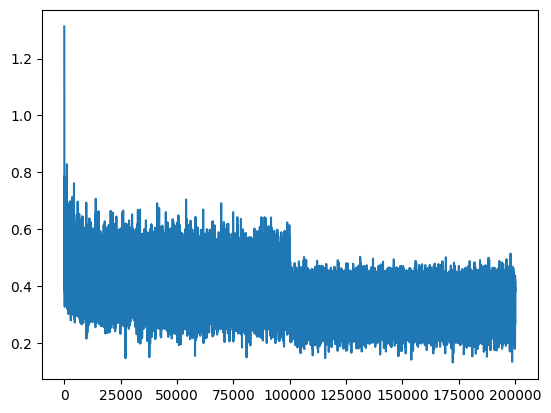

In [11]:
plt.plot(lossi)

In [ ]:
@torch.no_grad() # tells torch function below will not require gradients, therefore no need to track it
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    } [split]
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate vectors
    hpreact = embcat @ W1 + b1 # hidden layer preactivation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss fcn
    print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.528538942337036
val 2.528538942337036


In [15]:
# sample from model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmarxami.
hari.
kimric.
taty.
skanden.
jazonte.
delynn.
jareeigh.
kania.
chaii.
desleigph.
bry.
kin.
quint.
sulin.
alian.
quinathogijarysi.
jameelinsley.
dae.
oil.


Now lets do some improvements

## Initialization
At initialization, our initial loss is extremely high (20), which quickly decays to ~ 2. However, we expect the initial guess to be uniform since we have no prior info, which leads to loss of $-\log(1/27) = 3.3$. So our network is very confidently wrong (since probability of letter it predicts is high yet result is wrong)

In [21]:
n_embd = 10 # dimension of char embedding vector
n_hidden = 200 # n neurons per hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.rand((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # make logits smaller
b2 = torch.randn(vocab_size, generator=g) * 0 # make logits smaller

parameters = (C, W1, b1, W2, b2)
for p in parameters:
    p.requires_grad = True

In [22]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate vectors
    hpreact = embcat @ W1 + b1 # hidden layer preactivation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss fcn

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track state
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break


      0/ 200000: 3.2676


Making logits a lot smaller by scaling W2 and b2 makes initial loss a lot better. This allows us to spend more time actually optimizing the NN instead of having to squash down the logits.

## Next lets look at h:

In [28]:
n_embd = 10 # dimension of char embedding vector
n_hidden = 200 # n neurons per hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.rand((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # make logits smaller
b2 = torch.randn(vocab_size, generator=g) * 0 # make logits smaller

parameters = (C, W1, b1, W2, b2)
for p in parameters:
    p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate vectors
    hpreact = embcat @ W1 + b1 # hidden layer preactivation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss fcn

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track state
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.2676
  10000/ 200000: 2.5654
  20000/ 200000: 2.5551
  30000/ 200000: 2.4592
  40000/ 200000: 2.2749
  50000/ 200000: 2.3845
  60000/ 200000: 2.4980
  70000/ 200000: 2.4658
  80000/ 200000: 2.5218
  90000/ 200000: 2.5090
 100000/ 200000: 2.2274
 110000/ 200000: 2.0632
 120000/ 200000: 2.1549
 130000/ 200000: 2.3996
 140000/ 200000: 2.1311
 150000/ 200000: 2.1438
 160000/ 200000: 2.0075
 170000/ 200000: 1.8066
 180000/ 200000: 2.3564
 190000/ 200000: 2.0011


In [23]:
h.shape

torch.Size([32, 200])

(array([1756.,  175.,  131.,   85.,   89.,   88.,   51.,   62.,   31.,
          34.,   43.,   61.,   32.,   35.,   31.,   24.,   30.,   40.,
          28.,   41.,   27.,   23.,   20.,   30.,   35.,   24.,   31.,
          27.,   42.,   41.,   30.,   33.,   42.,   22.,   36.,   27.,
          33.,   33.,   55.,   46.,   53.,   40.,   79.,   68.,   76.,
          71.,  114.,  155.,  245., 1975.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

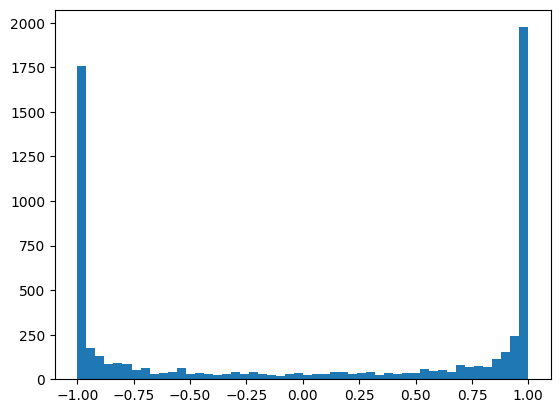

In [24]:
plt.hist(h.view(-1).tolist(), 50)

(array([  4.,   1.,   1.,   2.,   2.,   2.,   7.,  10.,  14.,  23.,  20.,
         49.,  55.,  78., 122., 133., 213., 227., 275., 267., 256., 295.,
        353., 353., 409., 398., 379., 396., 368., 327., 328., 232., 227.,
        171., 117.,  93.,  51.,  66.,  30.,  20.,  11.,   9.,   1.,   1.,
          2.,   1.,   0.,   0.,   0.,   1.]),
 array([-13.21240425, -12.67540545, -12.13840664, -11.60140783,
        -11.06440903, -10.52741022,  -9.99041142,  -9.45341261,
         -8.9164138 ,  -8.379415  ,  -7.84241619,  -7.30541739,
         -6.76841858,  -6.23141977,  -5.69442097,  -5.15742216,
         -4.62042336,  -4.08342455,  -3.54642574,  -3.00942694,
         -2.47242813,  -1.93542933,  -1.39843052,  -0.86143171,
         -0.32443291,   0.2125659 ,   0.7495647 ,   1.28656351,
          1.82356232,   2.36056112,   2.89755993,   3.43455873,
          3.97155754,   4.50855635,   5.04555515,   5.58255396,
          6.11955276,   6.65655157,   7.19355038,   7.73054918,
          8.267547

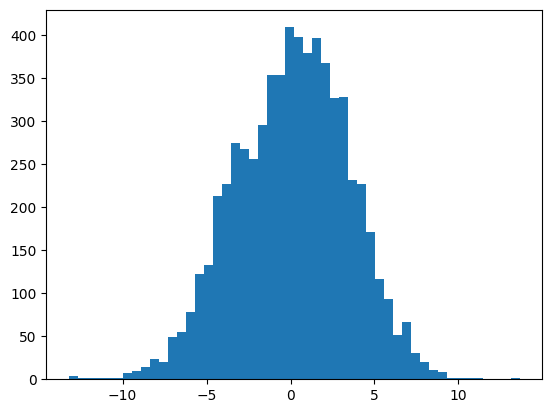

In [25]:
plt.hist(hpreact.view(-1).tolist(), 50)

Most of the values are -1 or 1 after tanh application, while before it the distribution is normal-like. Recall this is our tanh function (below), so any value of -1 or 1 kills the gradient from 1 - t**2

In [26]:
# def tanh(self):
#     x = self.data
#     t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
#     out = Value(t, (self, ), 'tanh')
    
#     def _backward():
#       self.grad += (1 - t**2) * out.grad
#     out._backward = _backward

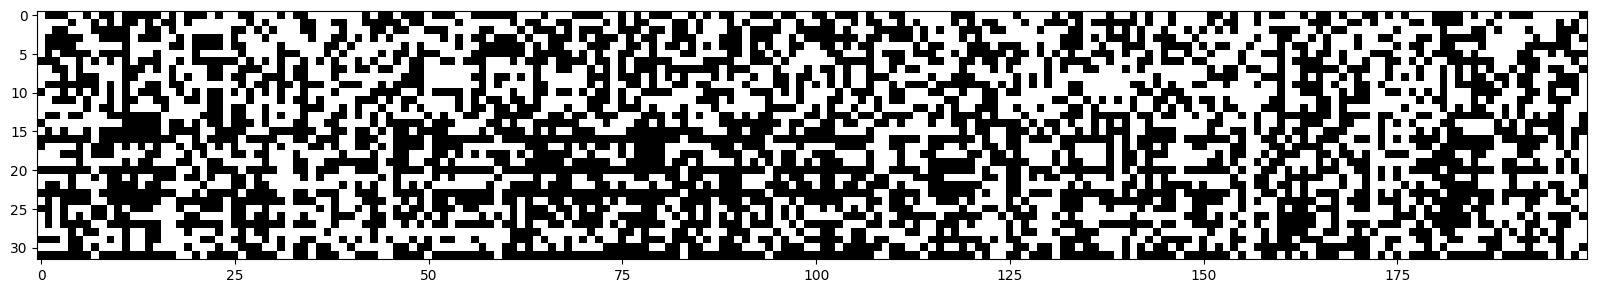

In [29]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

Any completely while column above means the neuron is completely dead, as white means abs(t) > 0.99 therefore gradient is 0. Dead neuron will never activate (during forward pass) nor learn (during backward pass) and always outputs either -1 or 1 no matter the input.

This is caused by hpreact being too large (range from -10 to 10). We can fix by scaling down W1 and b1

In [30]:
n_embd = 10 # dimension of char embedding vector
n_hidden = 200 # n neurons per hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.rand((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.1 # make hpreact smaller
b1 = torch.randn(n_hidden, generator=g) * 0.01 # make hpreact smaller
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # make logits smaller
b2 = torch.randn(vocab_size, generator=g) * 0 # make logits smaller

parameters = (C, W1, b1, W2, b2)
for p in parameters:
    p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate vectors
    hpreact = embcat @ W1 + b1 # hidden layer preactivation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss fcn

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track state
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break

      0/ 200000: 3.2841


(array([  6.,   4.,   6.,  15.,  16.,  25.,  53.,  41.,  45.,  95.,  84.,
         92., 115., 180., 140., 170., 233., 193., 165., 181., 203., 246.,
        286., 247., 252., 281., 217., 275., 263., 247., 287., 239., 220.,
        240., 183., 177., 164., 138.,  91.,  87.,  76.,  44.,  35.,  21.,
         11.,   5.,   3.,   2.,   0.,   1.]),
 array([-0.84609842, -0.81194565, -0.77779288, -0.74364011, -0.70948734,
        -0.67533457, -0.6411818 , -0.60702903, -0.57287626, -0.53872349,
        -0.50457072, -0.47041795, -0.43626518, -0.40211241, -0.36795964,
        -0.33380687, -0.2996541 , -0.26550133, -0.23134856, -0.19719579,
        -0.16304302, -0.12889025, -0.09473748, -0.06058471, -0.02643194,
         0.00772083,  0.0418736 ,  0.07602637,  0.11017914,  0.14433191,
         0.17848468,  0.21263745,  0.24679022,  0.28094299,  0.31509576,
         0.34924853,  0.3834013 ,  0.41755407,  0.45170684,  0.48585961,
         0.52001238,  0.55416515,  0.58831792,  0.62247069,  0.65662346,
 

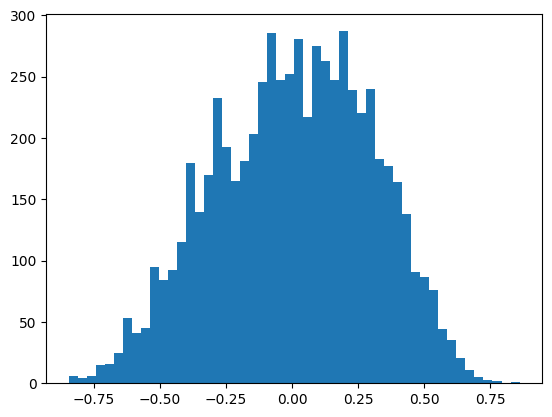

In [31]:
plt.hist(h.view(-1).tolist(), 50)

(array([  5.,   1.,   0.,   4.,   2.,   9.,  10.,  13.,  11.,  46.,  37.,
         40.,  90.,  89.,  98., 136., 212., 219., 272., 271., 248., 291.,
        397., 374., 373., 361., 403., 370., 393., 317., 308., 241., 221.,
        160., 102.,  99.,  75.,  31.,  31.,  21.,   8.,   4.,   1.,   3.,
          2.,   0.,   0.,   0.,   0.,   1.]),
 array([-1.24225831, -1.19142736, -1.14059641, -1.08976546, -1.03893451,
        -0.98810356, -0.93727261, -0.88644166, -0.8356107 , -0.78477975,
        -0.7339488 , -0.68311785, -0.6322869 , -0.58145595, -0.530625  ,
        -0.47979405, -0.4289631 , -0.37813215, -0.3273012 , -0.27647025,
        -0.2256393 , -0.17480834, -0.12397739, -0.07314644, -0.02231549,
         0.02851546,  0.07934641,  0.13017736,  0.18100831,  0.23183926,
         0.28267021,  0.33350116,  0.38433211,  0.43516306,  0.48599401,
         0.53682497,  0.58765592,  0.63848687,  0.68931782,  0.74014877,
         0.79097972,  0.84181067,  0.89264162,  0.94347257,  0.99430352,
 

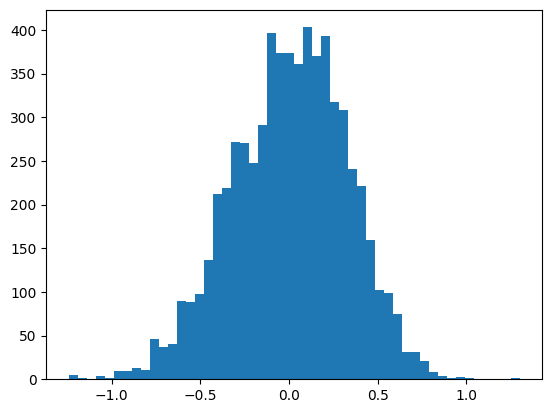

In [32]:
plt.hist(hpreact.view(-1).tolist(), 50)

hpreact now is between -1 and 1, much tighter range thus h is also less extreme

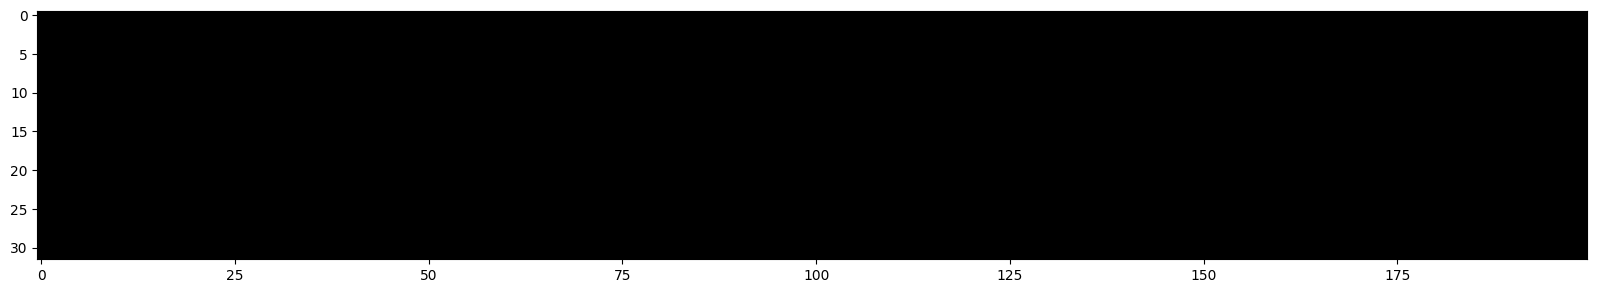

In [33]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

No saturated neurons (>0.99). This might be a bit extreme so we can increase W1 a bit. Now lets run the full optimization.

In [34]:
n_embd = 10 # dimension of char embedding vector
n_hidden = 200 # n neurons per hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.rand((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2 # make hpreact smaller
b1 = torch.randn(n_hidden, generator=g) * 0.01 # make hpreact smaller
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # make logits smaller
b2 = torch.randn(vocab_size, generator=g) * 0 # make logits smaller

parameters = (C, W1, b1, W2, b2)
for p in parameters:
    p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate vectors
    hpreact = embcat @ W1 + b1 # hidden layer preactivation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss fcn

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track state
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.2762
  10000/ 200000: 2.3785
  20000/ 200000: 2.4667
  30000/ 200000: 2.2122
  40000/ 200000: 2.2116
  50000/ 200000: 2.3050
  60000/ 200000: 2.6250
  70000/ 200000: 2.4398
  80000/ 200000: 2.5115
  90000/ 200000: 2.3504
 100000/ 200000: 2.0858
 110000/ 200000: 2.0010
 120000/ 200000: 2.0670
 130000/ 200000: 2.3494
 140000/ 200000: 2.3036
 150000/ 200000: 2.0873
 160000/ 200000: 1.9178
 170000/ 200000: 1.7766
 180000/ 200000: 2.2833
 190000/ 200000: 1.8952


In [35]:
@torch.no_grad() # tells torch function below will not require gradients, therefore no need to track it
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    } [split]
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate vectors
    hpreact = embcat @ W1 + b1 # hidden layer preactivation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss fcn
    print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.356050968170166
val 2.356050968170166


By fixing initialization, we decreased error by a good amount. These problems stack up even more if we get larger NNs.

## How to set scaling factors for weights and biases?
Previously we just did random ones, but how to be more precise?

tensor(0.0068) tensor(0.9909)
tensor(0.0017) tensor(3.1205)


(array([1.38813335e-05, 0.00000000e+00, 0.00000000e+00, 6.94066676e-06,
        6.94066676e-06, 6.94066676e-06, 4.85846673e-05, 7.63473343e-05,
        1.73516669e-04, 2.56804670e-04, 4.23380672e-04, 8.60642678e-04,
        1.27014202e-03, 2.42229270e-03, 4.24074739e-03, 6.54504875e-03,
        1.07857961e-02, 1.51167722e-02, 2.42506896e-02, 3.43007751e-02,
        4.88692346e-02, 6.63874775e-02, 8.74940451e-02, 1.05907634e-01,
        1.21739295e-01, 1.33968750e-01, 1.37071228e-01, 1.28728546e-01,
        1.13750587e-01, 9.32200952e-02, 7.38486943e-02, 5.60181214e-02,
        4.05057312e-02, 2.84567337e-02, 1.86426309e-02, 1.24376748e-02,
        7.87765677e-03, 4.98339873e-03, 3.22046938e-03, 1.78375136e-03,
        1.05498135e-03, 6.10778675e-04, 3.19270671e-04, 1.80457336e-04,
        1.04110001e-04, 4.16440005e-05, 6.24660008e-05, 2.08220003e-05,
        6.94066676e-06, 1.38813335e-05]),
 array([-18.87913895, -18.15874706, -17.43835518, -16.71796329,
        -15.99757141, -15.2771

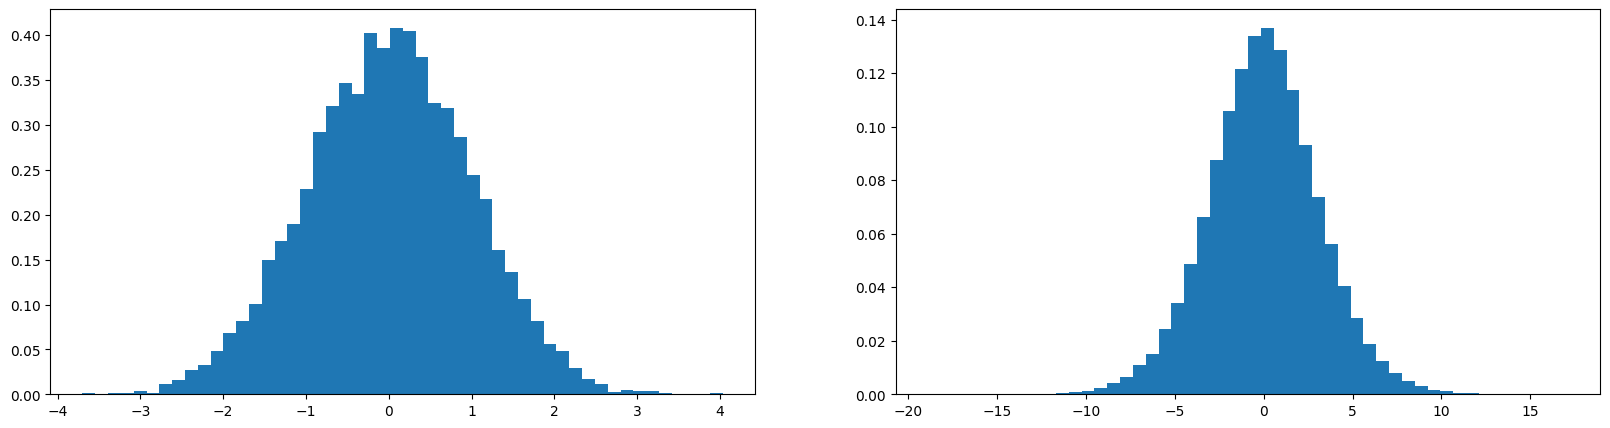

In [37]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize = (20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

From matrix multiplication of x and w, the distribution is growing (more std). We dont want this as we want NN to have similar activations (in particularly, std = 1). To do this, we divide w by sqrt(# input components = 10 here)

tensor(-0.0015) tensor(0.9944)
tensor(0.0007) tensor(0.9782)


(array([7.42062418e-05, 2.47354139e-05, 9.89416558e-05, 1.48412484e-04,
        2.72089553e-04, 7.42062418e-04, 6.67856177e-04, 1.48412484e-03,
        2.05303936e-03, 3.63610585e-03, 7.07432839e-03, 8.80580736e-03,
        1.51133379e-02, 2.26329038e-02, 3.30217776e-02, 4.87782363e-02,
        6.97538673e-02, 9.64928498e-02, 1.35104831e-01, 1.81607409e-01,
        2.35307993e-01, 2.90270083e-01, 3.46048441e-01, 3.92328401e-01,
        4.39869866e-01, 4.38212593e-01, 4.26809568e-01, 3.84239920e-01,
        3.26284845e-01, 2.73450001e-01, 2.09954194e-01, 1.61720136e-01,
        1.21154058e-01, 8.50898240e-02, 6.04038809e-02, 4.44000680e-02,
        2.95340843e-02, 2.00109499e-02, 1.31097694e-02, 8.31109909e-03,
        5.07075986e-03, 2.81983719e-03, 2.17671643e-03, 1.40991859e-03,
        5.44179107e-04, 6.18385349e-04, 1.97883312e-04, 7.42062418e-05,
        2.47354139e-05, 4.94708279e-05]),
 array([-5.11800098, -4.91586165, -4.71372232, -4.51158299, -4.30944366,
        -4.10730433, 

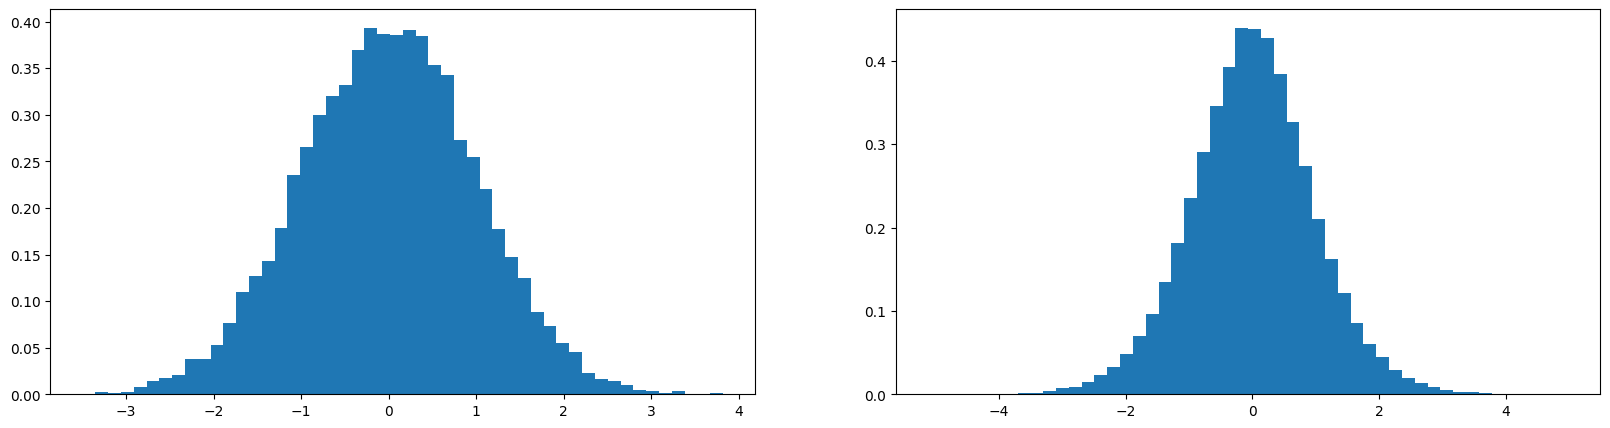

In [38]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10 ** 0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize = (20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

We also want to normalize the gradients to be standard normal. However, this is approximately accomplished by just normalizing the activations --aka fan-in-- (and vice versa). In particular, we multiply by the factor
$$ \frac{gain}{\sqrt(\text{fan-in})}$$
for tanh, fanin = 5/3

Going back to our W1

In [ ]:
n_embd = 10 # dimension of char embedding vector
n_hidden = 200 # n neurons per hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.rand((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/(n_embd * block_size)**0.5
b1 = torch.randn(n_hidden, generator=g) * 0.01 # make hpreact smaller
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # make logits smaller
b2 = torch.randn(vocab_size, generator=g) * 0 # make logits smaller

parameters = (C, W1, b1, W2, b2)
for p in parameters:
    p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate vectors
    hpreact = embcat @ W1 + b1 # hidden layer preactivation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss fcn

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track state
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

## Batch Normalization
hpreact too small: tanh pointless;

hpreact too large: tanh saturated;

want hpreact approximately standard normal

In [39]:
hpreact.shape

torch.Size([32, 200])

In [ ]:
hpreact.mean(0, keepdim=True).shape
hpreact.std(0, keepdim=True).shape # both are across dimension 0 (row)

torch.Size([1, 200])

In [ ]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate vectors
    hpreact = embcat @ W1 + b1 # hidden layer preactivation
    hpreact = (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True)
    # all operations differentiable
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss fcn

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track state
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

However, we only want hpreact to be gaussian on initialization, and want the NN to be able to modify it as we train. So we add 2 new parameters (bngain, bnbias) that are trained during backprop

In [49]:
n_embd = 10 # dimension of char embedding vector
n_hidden = 200 # n neurons per hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.rand((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/(n_embd * block_size)**0.5
b1 = torch.randn(n_hidden, generator=g) * 0.01 # make hpreact smaller
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # make logits smaller
b2 = torch.randn(vocab_size, generator=g) * 0 # make logits smaller

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((0, n_hidden))
bnstd_running = torch.zeros((1, n_hidden)) 


parameters = (C, W1, b1, W2, b2, bngain, bnbias)
for p in parameters:
    p.requires_grad = True


In [50]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate vectors
    hpreact = embcat @ W1 + b1 # hidden layer preactivation
    
    # BN layer
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani)/bnstdi + bnbias
    # all operations differentiable

    # update bnmean, bnstd not with GD
    with torch.no_grad():
        bnmean_running = 0.999* bnmean_running + 0.001 + bnmeani
        bnstd_running = 0.999* bnstd_running + 0.001 + bnstdi

    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss fcn

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track state
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.2875
  10000/ 200000: 2.3737
  20000/ 200000: 2.4984
  30000/ 200000: 2.1817
  40000/ 200000: 2.1189
  50000/ 200000: 2.3231
  60000/ 200000: 2.4467
  70000/ 200000: 2.5065
  80000/ 200000: 2.5669
  90000/ 200000: 2.4161
 100000/ 200000: 2.2112
 110000/ 200000: 2.1208
 120000/ 200000: 2.1433
 130000/ 200000: 2.3476
 140000/ 200000: 2.1957
 150000/ 200000: 2.1404
 160000/ 200000: 2.0487
 170000/ 200000: 1.8614
 180000/ 200000: 2.2229
 190000/ 200000: 2.0171


Note: we can remove b1 from above since its being added and subtracted subsequently when we demean. So in batch norm, the only bias that matters is bnbias

In general, the steps are

linear layer

batch norm layer
- as batch size increase, momentum can increase (We used 0.001)
- affine = True, to estimate bngain and bnbias
- track running calculates running mean and std

nonlinear layer

repeat

## Deep network
These are similar to torch implementations

In [108]:
# linear layer tools
 
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # train with GD
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers: train with running momentum update
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass calculation
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch var
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # buffer update
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
            
        return self.out
        
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []


In [62]:
# layer construction
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),    generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden), Tanh(),
    Linear(         n_hidden,   vocab_size),
]
with torch.no_grad():
    # make last layer less confident
    layers[-1].weight *= 0.1

    # apply gain to all other layers
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True

In [79]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1) # concatenate vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track state
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
      break

      0/ 200000: 2.7286


For each layer, looking at how many numbers take take on each value between -1 and 1. Our layers have stable saturation because we set gain = 5/3. If we set gain = 1, saturation of subsequent layers would approach 0. This is because tanh function squashes inputs.

layer 1 (      Tanh): mean -0.06, std 0.77, saturated: 22.47%
layer 3 (      Tanh): mean +0.01, std 0.75, saturated: 15.75%
layer 5 (      Tanh): mean +0.01, std 0.77, saturated: 18.53%
layer 7 (      Tanh): mean -0.05, std 0.77, saturated: 17.25%
layer 9 (      Tanh): mean -0.01, std 0.73, saturated: 13.53%


Text(0.5, 1.0, 'activation distribution')

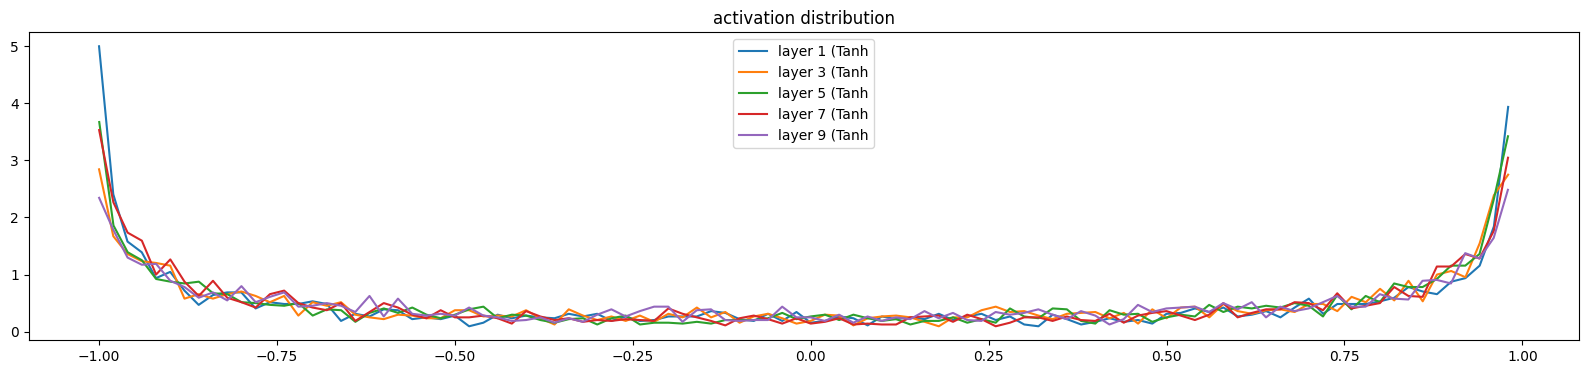

In [80]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

We want all layers to have similar gradient, no vanishing or exploding

layer 1 (      Tanh): mean +0.000098, std 2.791717e-03
layer 3 (      Tanh): mean +0.000015, std 2.677222e-03
layer 5 (      Tanh): mean +0.000031, std 2.790440e-03
layer 7 (      Tanh): mean -0.000049, std 2.865878e-03
layer 9 (      Tanh): mean +0.000019, std 2.589425e-03


Text(0.5, 1.0, 'gradient distribution')

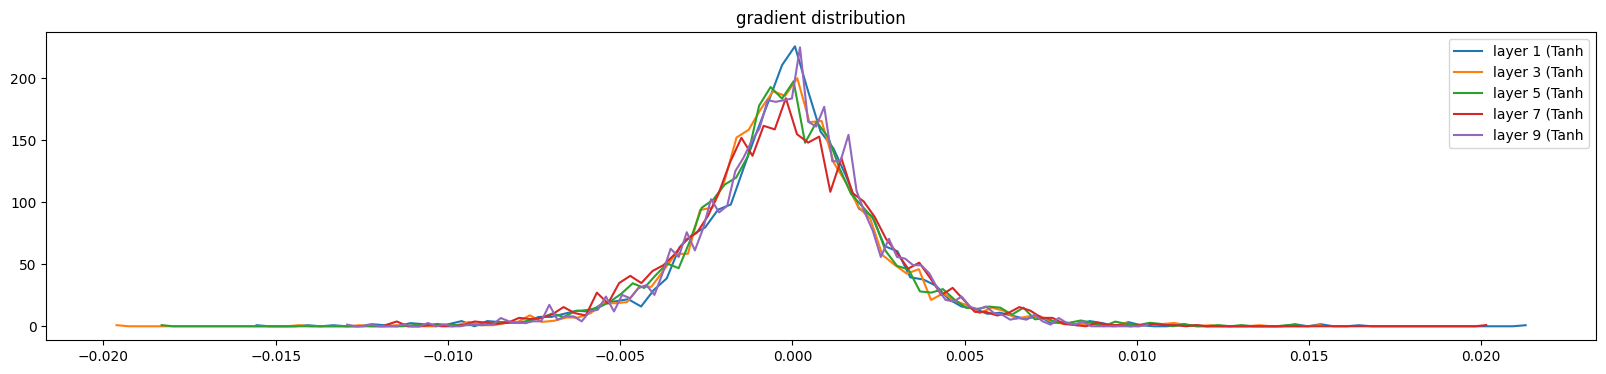

In [81]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

## Why Tanh?

If we only have purely linear layers, the relationship it encodes is entirely linear

weight   (27, 10) | mean +0.000238 | std 1.127277e-02 | grad:data ratio 1.119295e-02
weight  (30, 100) | mean +0.000003 | std 8.966796e-03 | grad:data ratio 2.823929e-02
weight (100, 100) | mean -0.000003 | std 7.311721e-03 | grad:data ratio 4.224760e-02
weight (100, 100) | mean -0.000061 | std 6.706876e-03 | grad:data ratio 3.866405e-02
weight (100, 100) | mean -0.000041 | std 6.880977e-03 | grad:data ratio 3.993421e-02
weight (100, 100) | mean -0.000024 | std 6.471283e-03 | grad:data ratio 3.811451e-02
weight  (100, 27) | mean -0.000000 | std 2.402556e-02 | grad:data ratio 2.692615e-01


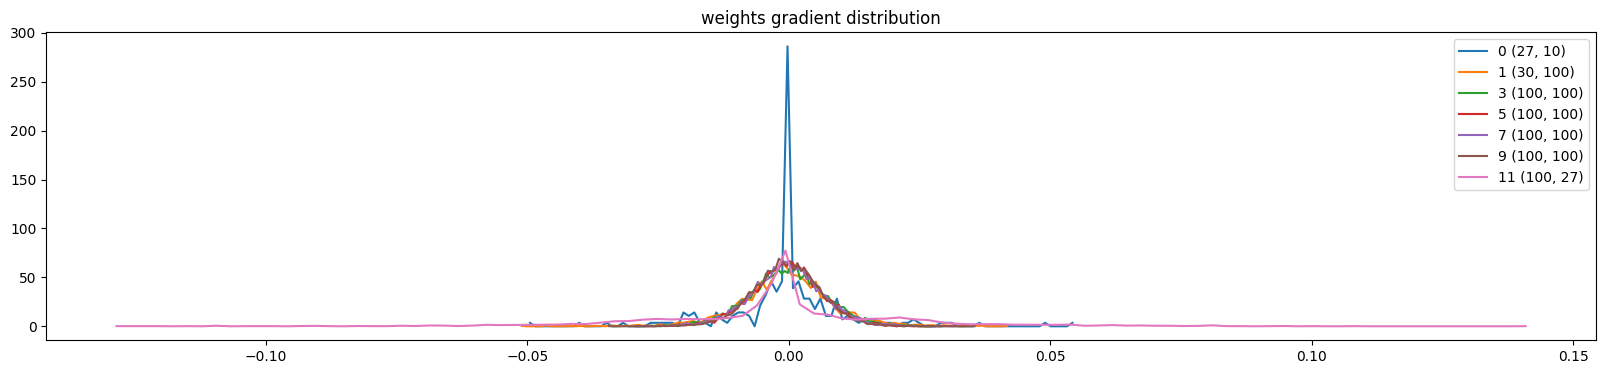

In [82]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

Cell below shows gradient to data ratio. If it is much below 10^-3 than the learning rate is too low. If LR too high than gradient lines wont converge, some will learn too fast or too slow

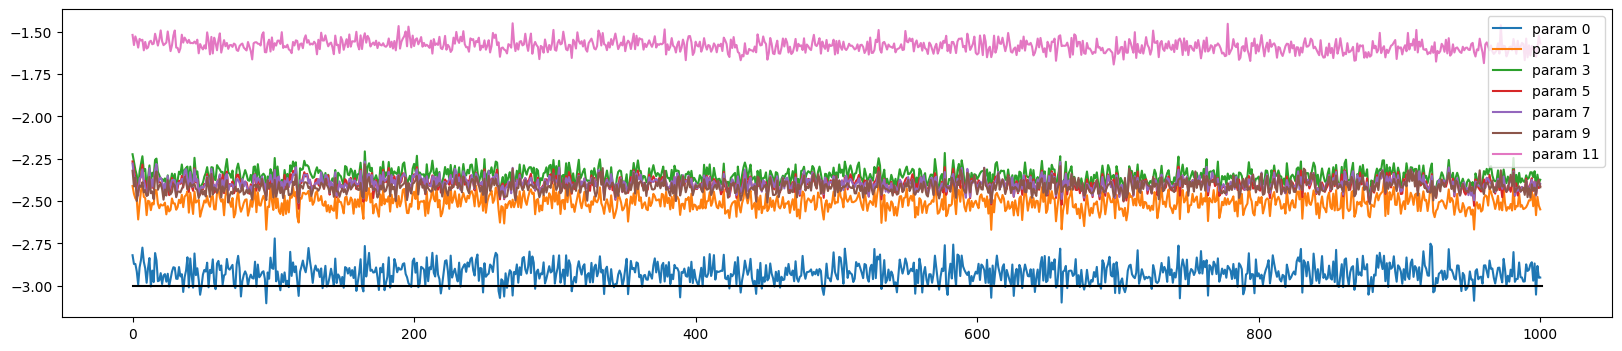

In [ ]:
# gradient to data ratio

plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

## Adding BatchNorm

In [109]:
# layer construction
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),    generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden,   n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden,   vocab_size, bias=False), BatchNorm1d(vocab_size),
]
with torch.no_grad():
    # make last layer less confident
    layers[-1].gamma *= 0.1

    # apply gain to all other layers
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True

In [110]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1) # concatenate vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track state
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
      break

      0/ 200000: 3.3136


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.69%
layer 5 (      Tanh): mean -0.00, std 0.65, saturated: 2.62%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.53%
layer 11 (      Tanh): mean +0.01, std 0.65, saturated: 1.53%
layer 14 (      Tanh): mean -0.00, std 0.65, saturated: 1.38%


Text(0.5, 1.0, 'activation distribution')

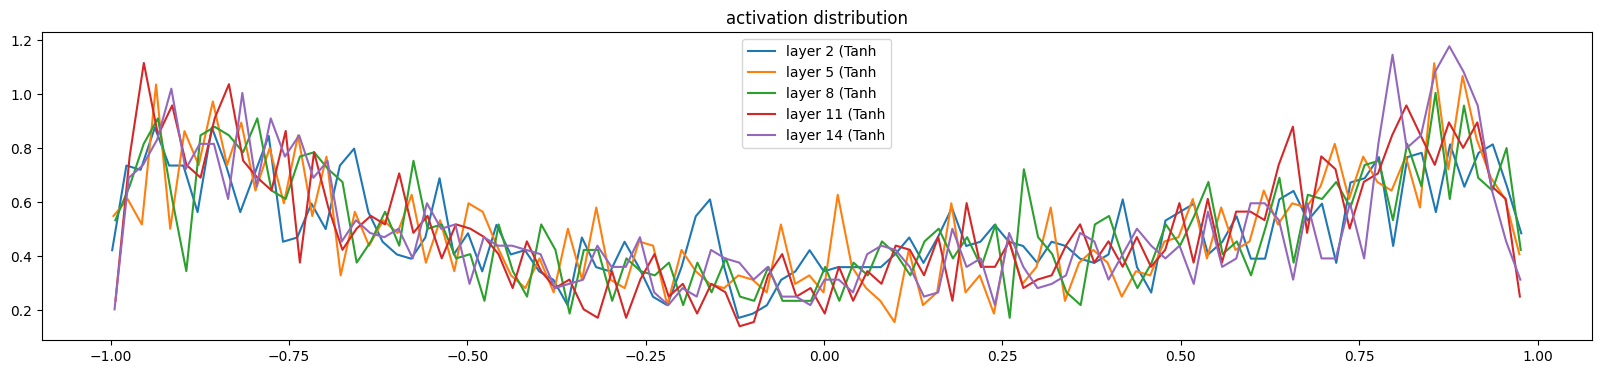

In [111]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 2.538456e-03
layer 5 (      Tanh): mean -0.000000, std 2.155138e-03
layer 8 (      Tanh): mean -0.000000, std 2.076223e-03
layer 11 (      Tanh): mean -0.000000, std 1.921736e-03
layer 14 (      Tanh): mean -0.000000, std 1.910291e-03


Text(0.5, 1.0, 'gradient distribution')

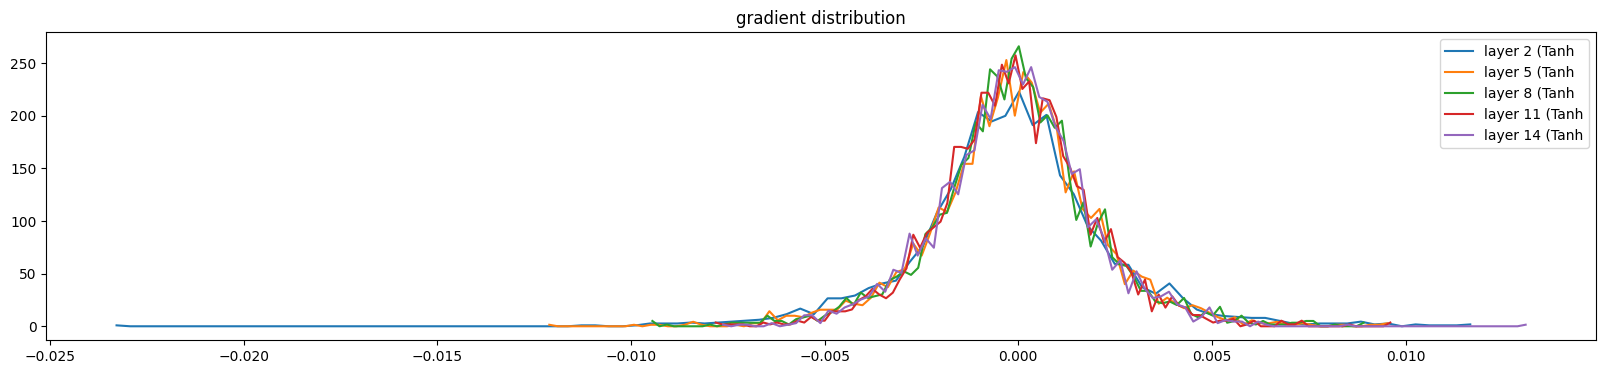

In [112]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 9.386816e-03 | grad:data ratio 9.377587e-03
weight  (30, 100) | mean +0.000006 | std 9.945584e-03 | grad:data ratio 5.253795e-02
weight (100, 100) | mean +0.000131 | std 7.455925e-03 | grad:data ratio 7.286056e-02
weight (100, 100) | mean -0.000008 | std 6.447962e-03 | grad:data ratio 6.285912e-02
weight (100, 100) | mean +0.000017 | std 5.940125e-03 | grad:data ratio 5.830502e-02
weight (100, 100) | mean +0.000068 | std 5.057413e-03 | grad:data ratio 4.969278e-02
weight  (100, 27) | mean +0.000006 | std 9.578422e-03 | grad:data ratio 9.201103e-02


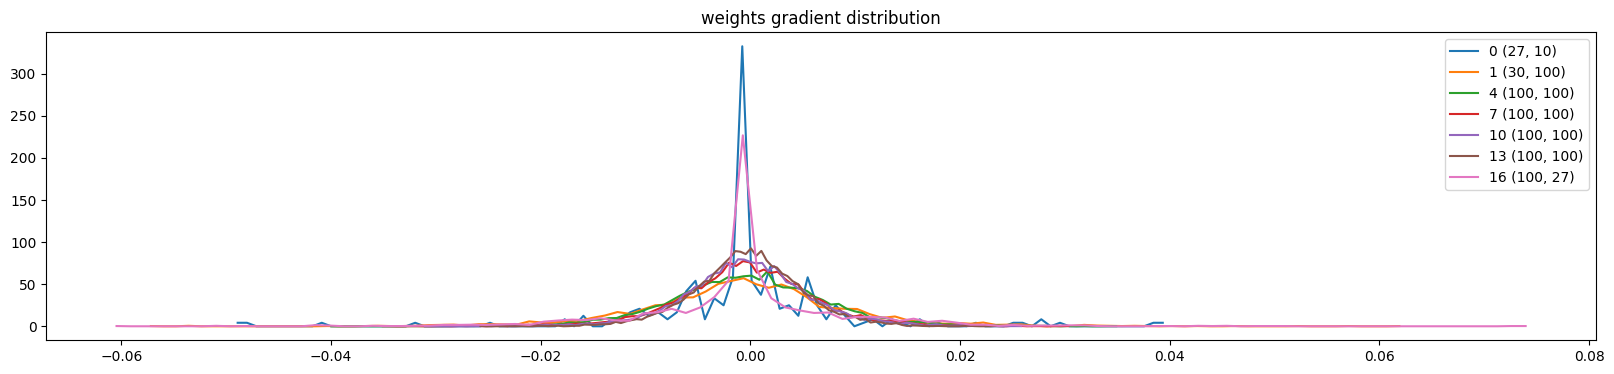

In [113]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

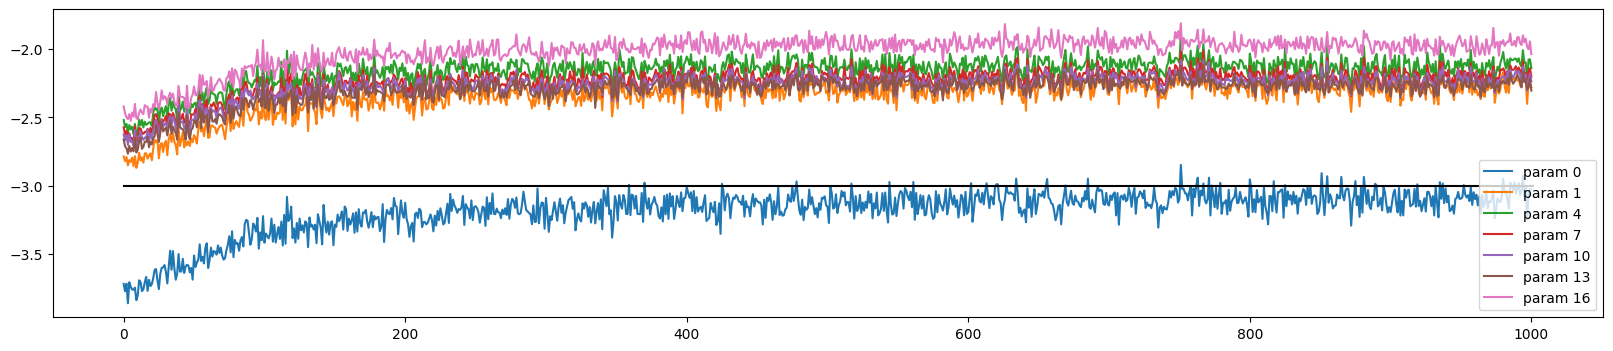

In [114]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);